# Модуль 7. Честное сравнение

Ноутбук к [модулю 7](https://drobyshevdev.github.io/lemma/modules/07-honest-comparison/).

Здесь ничего не обучается ради качества. Здесь измеряется, **насколько врут** привычные процедуры сравнения: выбор лучшего из двадцати, подглядывание в тест, нормализация до разбиения, случайное разбиение временного ряда.

Все четыре ошибки встречаются в опубликованных работах.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def fit_ridge(X, y, l2=1e-6):
    Xb = np.hstack([X, np.ones((len(X), 1))])
    A = Xb.T @ Xb + l2 * np.eye(Xb.shape[1])
    return np.linalg.solve(A, Xb.T @ y)

def predict(w, X):
    return np.hstack([X, np.ones((len(X), 1))]) @ w

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

## 1. Выбор лучшего из двадцати

Самый честный из четырёх сюжетов и самый недооценённый.

Двадцать моделей **одинакового качества** — отличаются только случайным подмножеством признаков. Выбираем лучшую по валидации и смотрим, что она покажет на честном тесте.

In [2]:
def experiment_selection(n_models=50, n_val=60, seed=0):
    rng = np.random.default_rng(seed)
    n, d = 900, 12
    X = rng.normal(0, 1, size=(n, d))
    y = X @ rng.normal(0, 1, d) + rng.normal(0, 1.5, n)

    tr = slice(0, 500)
    va = slice(500, 500 + n_val)
    te = slice(500 + n_val, n)

    val_scores, test_scores = [], []
    for _ in range(n_models):
        cols = rng.choice(d, 8, replace=False)          # модели-близнецы
        w = fit_ridge(X[tr][:, cols], y[tr])
        val_scores.append(rmse(predict(w, X[va][:, cols]), y[va]))
        test_scores.append(rmse(predict(w, X[te][:, cols]), y[te]))

    winner = int(np.argmin(val_scores))
    return val_scores[winner], test_scores[winner], float(np.mean(test_scores))

runs = np.array([experiment_selection(seed=s) for s in range(300)])
print(f"валидация победителя (то, что напишут в отчёте): {runs[:, 0].mean():.4f}")
print(f"тест победителя (честная оценка):                {runs[:, 1].mean():.4f}")
print(f"тест средней модели:                             {runs[:, 2].mean():.4f}")
print(f"\nзавышение от выбора победителя: {runs[:, 1].mean() - runs[:, 0].mean():+.4f} RMSE")

валидация победителя (то, что напишут в отчёте): 1.6754
тест победителя (честная оценка):                1.7747
тест средней модели:                             2.4554

завышение от выбора победителя: +0.0993 RMSE


Все двадцать моделей одинаково хороши по построению. Победитель победил удачей на валидации — и на тесте оказывается заметно хуже, чем обещал.

Это шестой пункт из модуля 1, множественные сравнения, в чистом виде. Тест существует ровно для того, чтобы поймать эту разницу.

**Сломайте:** увеличьте `n_val` до 2000. Уменьшается ли завышение? А если моделей не 20, а 200?

## 2. K-fold и разброс между фолдами

Одно разбиение даёт одно число. Из модуля 1 известно, чего оно стоит.

In [3]:
def kfold_scores(X, y, k=5, l2=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    folds = np.array_split(idx, k)
    out = []
    for i in range(k):
        test = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        w = fit_ridge(X[train], y[train], l2)
        out.append(rmse(predict(w, X[test]), y[test]))
    return np.array(out)

rng = np.random.default_rng(2)
n, d = 400, 6
Xk = rng.normal(0, 1, size=(n, d))
yk = Xk @ rng.normal(0, 1, d) + rng.normal(0, 1.2, n)

a = kfold_scores(Xk, yk, l2=1e-6)
b = kfold_scores(Xk, yk, l2=5.0)          # чуть другая модель

print(f"модель A по фолдам: {np.round(a, 3)}   среднее {a.mean():.3f}")
print(f"модель B по фолдам: {np.round(b, 3)}   среднее {b.mean():.3f}")
print(f"\nразница средних:        {abs(a.mean() - b.mean()):.4f}")
print(f"разброс между фолдами:  {a.std(ddof=1):.4f}")
print("\nРазброс больше разницы. По правилу модуля 1 -- разница не показана.")

модель A по фолдам: [1.254 1.183 1.426 1.073 1.287]   среднее 1.245
модель B по фолдам: [1.259 1.18  1.43  1.068 1.283]   среднее 1.244

разница средних:        0.0007
разброс между фолдами:  0.1306

Разброс больше разницы. По правилу модуля 1 -- разница не показана.


## 3. Подглядывание в тест

Шестьдесят раз, каждый раз оставляли вариант, если он оказался лучше. Никакого злого умысла — так выглядит обычная работа над задачей.

In [4]:
def peeking(n_iterations=60, seed=0):
    rng = np.random.default_rng(seed)
    n, d = 1200, 15
    X = rng.normal(0, 1, size=(n, d))
    y = X @ rng.normal(0, 1, d) + rng.normal(0, 1.5, n)

    tr, te, holdout = slice(0, 400), slice(400, 500), slice(500, n)

    best_on_test, best_cols = np.inf, None
    trajectory = []
    for _ in range(n_iterations):
        cols = rng.choice(d, 9, replace=False)
        w = fit_ridge(X[tr][:, cols], y[tr])
        score = rmse(predict(w, X[te][:, cols]), y[te])
        if score < best_on_test:                      # оставляем, раз лучше
            best_on_test, best_cols, best_w = score, cols, w
        trajectory.append(best_on_test)
    honest = rmse(predict(best_w, X[holdout][:, best_cols]), y[holdout])
    return np.array(trajectory), honest

results = [peeking(seed=s) for s in range(200)]
traj = np.mean([t for t, _ in results], axis=0)
honest = np.mean([h for _, h in results])

print(f"после 1 итерации  «тест» показывает: {traj[0]:.4f}")
print(f"после {len(traj)} итераций «тест» показывает: {traj[-1]:.4f}")
print(f"нетронутая выборка показывает:       {honest:.4f}")
print(f"\nсамообман: {honest - traj[-1]:+.4f} RMSE")

после 1 итерации  «тест» показывает: 2.8740
после 60 итераций «тест» показывает: 1.9424
нетронутая выборка показывает:       2.0126

самообман: +0.0702 RMSE


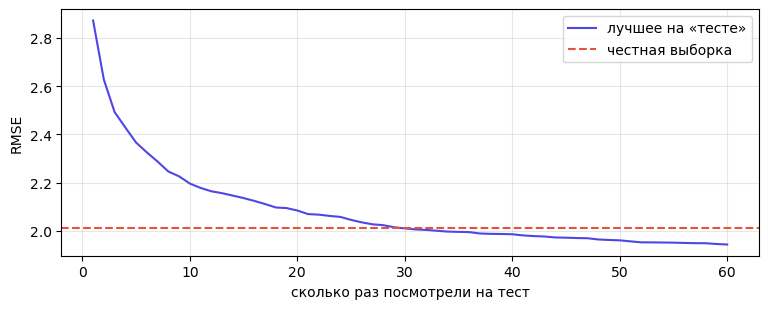

In [5]:
fig, ax = plt.subplots()
ax.plot(range(1, len(traj) + 1), traj, color="#4f46e5", label="лучшее на «тесте»")
ax.axhline(honest, color="#e5533c", ls="--", lw=1.5, label="честная выборка")
ax.set_xlabel("сколько раз посмотрели на тест")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()

Синяя линия ползёт вниз, потому что мы выбираем лучшее из всё большего числа попыток. Красная стоит на месте: настоящее качество не меняется.

Расстояние между ними — это ровно то, насколько вы себя обманули. Данные при этом не трогали, код честный, ошибок нет. **Каналом утечки стали вы.**

## 4. Утечка через нормализацию до разбиения

Самая частая техническая утечка. Измерим, сколько она дарит.

In [6]:
def leak_experiment(n=80, d=60, seed=0):
    """Признаков больше, чем объектов, цель -- чистый шум.

    Правильная процедура обязана показать «связи нет».
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, d))
    y = rng.normal(0, 1, n)                      # никакой связи с X

    # Неправильно: отбираем признаки по всем данным, потом разбиваем.
    corr_all = np.abs(X.T @ (y - y.mean())) / n
    top_leaky = np.argsort(-corr_all)[:5]

    tr, te = slice(0, 50), slice(50, n)
    w = fit_ridge(X[tr][:, top_leaky], y[tr], 1e-3)
    leaky = rmse(predict(w, X[te][:, top_leaky]), y[te])

    # Правильно: отбираем только по обучающей части.
    corr_tr = np.abs(X[tr].T @ (y[tr] - y[tr].mean())) / 50
    top_clean = np.argsort(-corr_tr)[:5]
    w = fit_ridge(X[tr][:, top_clean], y[tr], 1e-3)
    clean = rmse(predict(w, X[te][:, top_clean]), y[te])

    return leaky, clean, float(y[te].std())

res = np.array([leak_experiment(seed=s) for s in range(400)])
print(f"отбор по всем данным (утечка): RMSE {res[:, 0].mean():.4f}")
print(f"отбор только по обучению:      RMSE {res[:, 1].mean():.4f}")
print(f"разброс самой цели:            RMSE {res[:, 2].mean():.4f}")
print("\nСвязи в данных нет вообще. Честная процедура это и показывает.")
print("Утечка рисует улучшение из ничего.")

отбор по всем данным (утечка): RMSE 0.9473
отбор только по обучению:      RMSE 1.1227
разброс самой цели:            RMSE 0.9679

Связи в данных нет вообще. Честная процедура это и показывает.
Утечка рисует улучшение из ничего.


Цель — чистый шум, никакой зависимости нет. Честный отбор признаков честно не находит ничего. Отбор по всем данным сразу находит «сигнал», потому что он подсмотрел, какие признаки случайно похожи на цель **в тестовой части**.

Симптом ровно тот, что описан в тексте: метрика внезапно стала лучше. Приятная неожиданность.

## 5. Групповая утечка

Один пользователь оставил несколько записей, и они разъехались по обучению и тесту.

In [7]:
rng = np.random.default_rng(5)
n_users, per_user, d = 120, 8, 5
user = np.repeat(np.arange(n_users), per_user)
user_effect = rng.normal(0, 2.0, n_users)          # у каждого свой уровень

Xg = rng.normal(0, 1, size=(len(user), d))
yg = Xg @ rng.normal(0, 0.5, d) + user_effect[user] + rng.normal(0, 0.3, len(user))

# Наивно: перемешиваем строки.
idx = rng.permutation(len(user))
cut = int(0.7 * len(user))
naive_tr, naive_te = idx[:cut], idx[cut:]

# Правильно: делим пользователей, а не строки.
users_shuffled = rng.permutation(n_users)
train_users = set(users_shuffled[:int(0.7 * n_users)].tolist())
group_tr = np.array([i for i in range(len(user)) if user[i] in train_users])
group_te = np.array([i for i in range(len(user)) if user[i] not in train_users])

def with_user_feature(X, u):
    return np.hstack([X, u[:, None].astype(float)])   # ID пользователя как признак

Xu = with_user_feature(Xg, user)
for name, tr, te in [("случайное разбиение строк", naive_tr, naive_te),
                     ("разбиение по пользователям", group_tr, group_te)]:
    w = fit_ridge(Xu[tr], yg[tr], 1e-3)
    print(f"{name:<28} RMSE {rmse(predict(w, Xu[te]), yg[te]):.4f}")

случайное разбиение строк    RMSE 1.7129
разбиение по пользователям   RMSE 1.9411


При случайном разбиении модель видит того же пользователя и в обучении, и в тесте. Она запоминает его уровень и получает хорошую метрику.

На новом пользователе, которого в обучении не было, запоминать нечего — и цифра честная. Разница между строками и есть цена ошибки разбиения.

**Сломайте:** уберите ID пользователя из признаков. Исчезнет ли утечка полностью? Подумайте, через что ещё модель может узнать пользователя.

## 6. Временной ряд

Перемешать данные во времени — значит обучиться на будущем и померить на прошлом.

In [8]:
rng = np.random.default_rng(7)
T = 800
t = np.arange(T)
level = np.cumsum(rng.normal(0, 0.3, T))          # блуждание: уровень дрейфует
series = level + 2.0 * np.sin(t / 30) + rng.normal(0, 0.4, T)

LAG = 5
Xt = np.stack([series[i:T - LAG + i] for i in range(LAG)], axis=1)

# Связь между прошлым и будущим медленно меняется -- так ведут себя почти все
# настоящие ряды: спрос, цены, поведение пользователей.
drift = np.linspace(-1.0, 1.0, len(Xt))
yt = series[LAG:] + drift * Xt[:, -1] * 0.9

shuffled = rng.permutation(len(yt))
cut = int(0.7 * len(yt))

w_shuffled = fit_ridge(Xt[shuffled[:cut]], yt[shuffled[:cut]])
shuffled_score = rmse(predict(w_shuffled, Xt[shuffled[cut:]]), yt[shuffled[cut:]])

w_time = fit_ridge(Xt[:cut], yt[:cut])
time_score = rmse(predict(w_time, Xt[cut:]), yt[cut:])

print(f"случайное разбиение:   RMSE {shuffled_score:.4f}")
print(f"разбиение по времени:  RMSE {time_score:.4f}")
print(f"\nразница: {time_score / shuffled_score:.2f}x")

случайное разбиение:   RMSE 4.3082
разбиение по времени:  RMSE 10.9418

разница: 2.54x


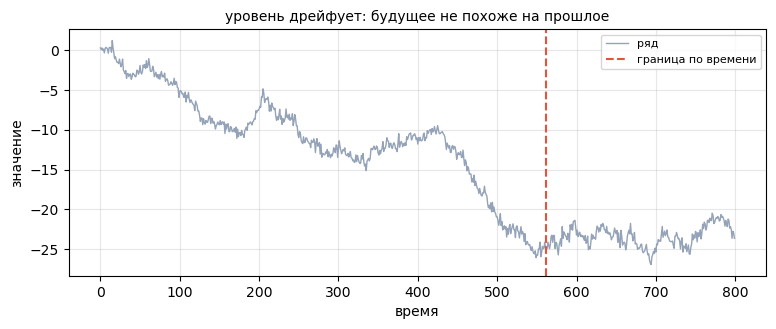

In [9]:
fig, ax = plt.subplots()
ax.plot(t, series, lw=1, color="#94a3b8", label="ряд")
ax.axvline(cut + LAG, color="#e5533c", ls="--", lw=1.5, label="граница по времени")
ax.set_xlabel("время"); ax.set_ylabel("значение"); ax.legend(fontsize=8)
ax.set_title("уровень дрейфует: будущее не похоже на прошлое", fontsize=10)
plt.show()

Случайное разбиение даёт метрику лучше, и она ничего не значит: соседние точки ряда почти одинаковы, и попав в разные выборки, они превращают задачу в списывание.

Разбиение по времени отвечает на настоящий вопрос: что будет на данных, которых ещё не было.

## 7. Журнал прогонов

Двадцать строк, которые через полгода отвечают на вопрос «откуда взялось это число».

In [10]:
import csv, datetime, io, subprocess

def git_commit():
    try:
        out = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                             capture_output=True, text=True, timeout=5)
        return out.stdout.strip() or "no-git"
    except Exception:
        return "no-git"

FIELDS = ["time", "commit", "model", "params", "seed", "data", "val", "test"]

def log_run(sink, **row):
    row.setdefault("time", datetime.datetime.now().isoformat(timespec="seconds"))
    row.setdefault("commit", git_commit())
    row.setdefault("test", "")            # пусто, пока тест не открывали
    csv.DictWriter(sink, FIELDS).writerow({k: row.get(k, "") for k in FIELDS})

sink = io.StringIO()
csv.DictWriter(sink, FIELDS).writeheader()

for l2 in [1e-6, 0.1, 5.0]:
    scores = kfold_scores(Xk, yk, l2=l2, seed=0)
    log_run(sink, model="ridge", params=f"l2={l2}", seed=0,
            data="synthetic n=400 d=6", val=f"{scores.mean():.4f}")

print(sink.getvalue())
print("Колонка test пустая: тест ещё не открывали. Так и должно быть")
print("до самого конца работы над задачей.")

time,commit,model,params,seed,data,val,test
2026-08-03T23:49:48,cb7d60e,ridge,l2=1e-06,0,synthetic n=400 d=6,1.2446,
2026-08-03T23:49:48,cb7d60e,ridge,l2=0.1,0,synthetic n=400 d=6,1.2446,
2026-08-03T23:49:48,cb7d60e,ridge,l2=5.0,0,synthetic n=400 d=6,1.2439,

Колонка test пустая: тест ещё не открывали. Так и должно быть
до самого конца работы над задачей.


Проверка качества журнала одна: **можно ли по записи воспроизвести число.** Здесь есть коммит кода, зерно, параметры и описание данных — можно.

Формат вторичен. CSV, который вы действительно ведёте, лучше инструмента, который поставили и забыли.

## Итог

Часть II закончена. Что измерено, а не рассказано:

1. Победитель из двадцати одинаковых моделей на тесте заметно хуже, чем обещал на валидации.
2. Разброс между фолдами регулярно больше разницы между сравниваемыми моделями.
3. Шестьдесят взглядов на тест сдвигают оценку на величину, которую вы уже не увидите.
4. Отбор признаков по всем данным находит сигнал там, где его нет вообще.
5. Случайное разбиение по строкам вместо пользователей даёт метрику лучше настоящей.
6. Перемешанный временной ряд отвечает на вопрос, которого никто не задавал: разница в 2.5 раза.
7. Журнал прогонов из семи колонок делает число воспроизводимым через полгода.

Ни одна из шести ошибок не требует злого умысла, плохого кода или неверных данных. Все шесть встречаются в опубликованных работах.

Дальше — [часть III](https://drobyshevdev.github.io/lemma/programme/): нейросети. Всё, что там появится, сравнивается с бустингом из модуля 6 по правилам этого модуля.